In [127]:
import matplotlib as plt
import pandas as pd
from pymatreader import  read_mat
import numpy as np
import seaborn as sns
from pathlib import Path

# matlab_filenames = ["output/defaults.mat", "output/no_rock.mat", "output/no_water.mat",
#                     "output/big_patches.mat", "output/small_patches.mat"]
# figure_prefix = "comparison"
# x_label = "Scenario"

matlab_filenames = ["output/R_perc_1.mat", "output/R_perc_2.mat", "output/R_perc_3.mat",  
                    "output/R_perc_4.mat", "output/R_perc_5.mat"]
figure_prefix = "R_perc"
x_label = "Perception Range"

# Plotting
habitat_colours = ["#85522E", "#B8E047", "#14731F", "#1F6BD1"]
def save_figure(label):
    fig = plt.pyplot.gcf()
    fig.set_size_inches(8,3.5)
    # lgd = plt.pyplot.gca().get_legend()
    # if lgd is None:
    #     fig.delaxes(fig.axes[-1]) 
    # else:
    #     lgd.remove()
    fig.savefig("figures/" + figure_prefix + "-" + label + ".png")

# Loading in data
def load_matlab_data(matlab_filename, array_name):
    mat_data = read_mat(matlab_filename)
    # Extract the time values
    deltaT = mat_data["params"]['deltaT'][0]
    T0 = mat_data["params"]['T0'][0]
    time_mins = [T0 + i*deltaT for i in range(len(mat_data[array_name][0]))]
    # Skip first day or two
    n_days_skip = 2
    n_timesteps_skip = int(n_days_skip*24*60/5)
    time_mins = time_mins[n_timesteps_skip:]
    frog_data = [frog[n_timesteps_skip:] for frog in mat_data[array_name]]
    # Return the time data, the frog data, and the parameters
    return (mat_data["params"], time_mins, frog_data)

Text(0, 0.5, 'y')

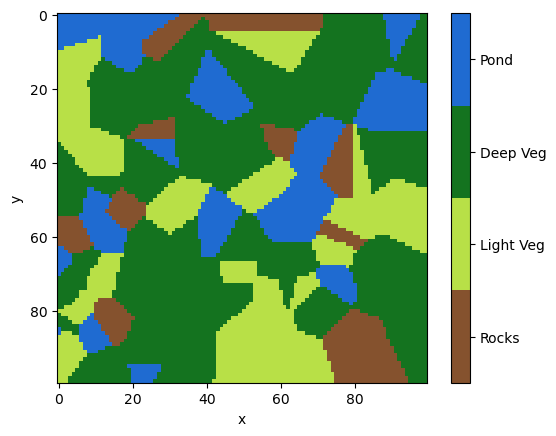

In [128]:
mat_data = read_mat(matlab_filenames[0])
cmap = plt.colors.ListedColormap(habitat_colours)
img = plt.pyplot.imshow(
    mat_data["habitat"],
    cmap=cmap,
    vmin=0.5,
    vmax=4.5,
    interpolation="nearest",
    origin="lower"
)
plt.pyplot.gca().invert_yaxis()

cbar = plt.pyplot.colorbar(img, ticks=[1,2,3,4])
cbar.ax.set_yticklabels(mat_data["params"]["habitat_labels"])

plt.pyplot.xlabel("x")
plt.pyplot.ylabel("y")



## Residence times

In [129]:
# Load in the residence time data
def get_residence_times(matlab_filename):
    # Get the habitat data from the matlab data
    (params, time_mins, frog_habitats) = load_matlab_data(matlab_filename, "output_habitats")
    # Convert to a dataframe of residence times
    residence_time_df = pd.DataFrame(columns=["frog", "habitat", "residence_time_mins", "entry_time_mins"])
    deltaT = params["deltaT"][0]
    for id,frog_hab in enumerate(frog_habitats):
        hab_change_idxs = np.where(np.diff(frog_hab.astype(int)) != 0) # Skip the first as we won't observe it
        output_df = pd.DataFrame({"residence_time_mins": np.diff(hab_change_idxs)[0]*deltaT})
        output_df["habitat"] = frog_hab[[idx + 1 for idx in hab_change_idxs[0][:-1]]]
        output_df["entry_time_mins"] = [time_mins for idx in hab_change_idxs[0][:-1]]
        output_df["frog"] = id
        residence_time_df = pd.concat([residence_time_df, output_df], ignore_index=True)
    # Return
    return (params, residence_time_df)
# Run for each matlab file
res_data = {Path(filename).stem: get_residence_times(filename) for filename in matlab_filenames}
keys = [key for key in res_data.keys()]
print(keys)

['R_perc_1', 'R_perc_2', 'R_perc_3', 'R_perc_4', 'R_perc_5']


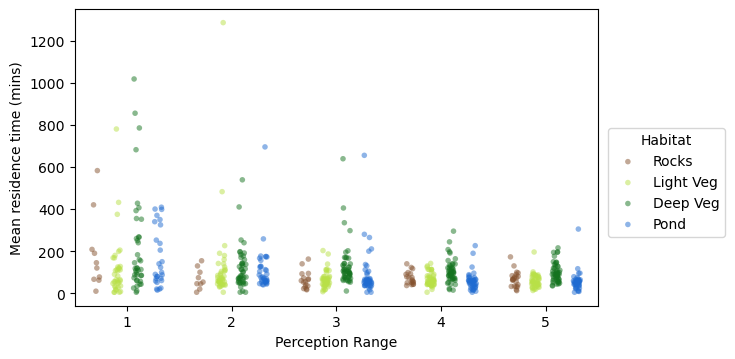

In [130]:
# Plot the averages for each habitat
residence_time_avg = pd.concat(
    [
        res_data[key][1]
        .groupby(["frog", "habitat"], as_index=False)["residence_time_mins"]
        .mean()
        .assign(scenario=key)
        for key in res_data
    ],
    ignore_index=True
)

sns.stripplot(
    data=residence_time_avg,
    x="scenario",
    y="residence_time_mins",
    hue="habitat",
    palette=habitat_colours,
    dodge=True,
    jitter=0.15,
    alpha=0.5,
    size=4,
    linewidth=0
)

# Formatting
plt.pyplot.legend(res_data[keys[0]][0]['habitat_labels'], title="Habitat",
                  bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.xlabel(x_label)
plt.pyplot.xticks(
    ticks=range(len(res_data)),
    labels=[scenario.replace("R_perc_", "").replace("_"," ").title() for scenario in res_data.keys()]
)
plt.pyplot.ylabel("Mean residence time (mins)")
plt.pyplot.tight_layout()

save_figure("residence_times")


## Body temperature

In [131]:
# Load in the body temperature data
def get_body_temperature(matlab_filename):
    # Load the data from matlab
    (params, time_mins, frog_temps) = load_matlab_data(matlab_filename, "output_frog_temp")
    # Convert to a data frame
    frog_temps_df = pd.concat([pd.DataFrame({"frog": frog, "time_mins": time_mins, "body_temp": temperature}) 
                           for frog, temperature in enumerate(frog_temps)])
    # Return
    return (params, frog_temps_df)
# Run for each matlab file
T_data = {Path(filename).stem: get_body_temperature(filename) for filename in matlab_filenames}
print([key for key in T_data.keys()])

['R_perc_1', 'R_perc_2', 'R_perc_3', 'R_perc_4', 'R_perc_5']


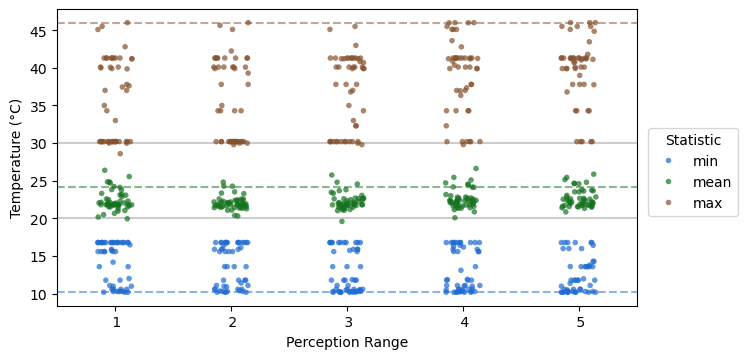

In [132]:
# Plot the averages for each habitat
frog_temp_stats = pd.concat(
    [
        T_data[key][1]
        .groupby("frog", as_index=False)
        .agg(
            mean=("body_temp", "mean"),
            min=("body_temp", "min"),
            max=("body_temp", "max"),
        )
        .assign(scenario=key)
        for key in T_data
    ],
    ignore_index=True
).melt(
    id_vars=["frog", "scenario"],
    value_vars=["min", "mean", "max"],
    var_name="metric",
    value_name="value"
)

sns.stripplot(
    data=frog_temp_stats,
    x="scenario",
    y="value",
    hue="metric",
    palette=[habitat_colours[i] for i in [3,2,0]],
    dodge=False,
    jitter=0.15,
    alpha=0.7,
    size=4,
    linewidth=0
)

# Formatting
plt.pyplot.legend(title="Statistic", bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.xlabel(x_label)
plt.pyplot.xticks(
    ticks=range(len(res_data)),
    labels=[scenario.replace("R_perc_", " ").replace("_"," ").title() for scenario in res_data.keys()]
)
plt.pyplot.ylabel("Temperature (°C)")


# Plot
# Add a line for VTmin and VTmax
ax = plt.pyplot.gca()
ax.axhline(T_data[keys[0]][0]["VTmax"][0], color="black", linestyle="-", alpha=0.2)
ax.axhline(T_data[keys[0]][0]["VTmin"][0], color="black", linestyle='-', alpha=0.2)

# Now add lines for the min, avg, and max temperatures
mat_data = read_mat(matlab_filenames[0])
temp_flat = [item for sublist in mat_data["habitat_temp_profile_hourly"] for item in sublist]
ax.axhline(np.min(temp_flat), color=habitat_colours[3], linestyle='--', alpha=0.5)
ax.axhline(np.mean(temp_flat), color=habitat_colours[2], linestyle='--', alpha=0.5)
ax.axhline(np.max(temp_flat), color=habitat_colours[0], linestyle='--', alpha=0.5)
plt.pyplot.tight_layout()

save_figure("body_temperature")


## Displacement

In [133]:
# Load in the frog movement data
def get_frog_movement(matlab_filename):
    # Load the data from matlab
    (params, time_mins, frog_locs) = load_matlab_data(matlab_filename, "output_locations")
    # Create a data frame of frog locations
    frog_loc_df = pd.DataFrame(columns=["frog", "time", "rmsd"])
    for frog_id, frog_loc_arr in enumerate(frog_locs):
        frog_loc_arr_float = np.asarray(frog_loc_arr, dtype=float)
        x0 = frog_loc_arr[0][0]
        y0 = frog_loc_arr[0][1]
        dx = [(x[0] - x0) for x in frog_loc_arr_float]
        dy = [(x[1] - y0) for x in frog_loc_arr_float]
        rmsd = [np.sqrt(x*x + y*y) for x, y in zip(dx, dy)]
        frog_loc_df = pd.concat([frog_loc_df, pd.DataFrame({
                "frog": [frog_id] * len(time_mins), "time": time_mins, 
                "x": [x[0] for x in frog_loc_arr_float], "y": [x[1] for x in frog_loc_arr_float],
                "rmsd": rmsd})], ignore_index=True)
    # print(frog_loc_df)
    
    # Return
    return (params, frog_loc_df)

# Run for each matlab file
loc_data = {Path(filename).stem: get_frog_movement(filename) for filename in matlab_filenames}
print([key for key in loc_data.keys()])

['R_perc_1', 'R_perc_2', 'R_perc_3', 'R_perc_4', 'R_perc_5']


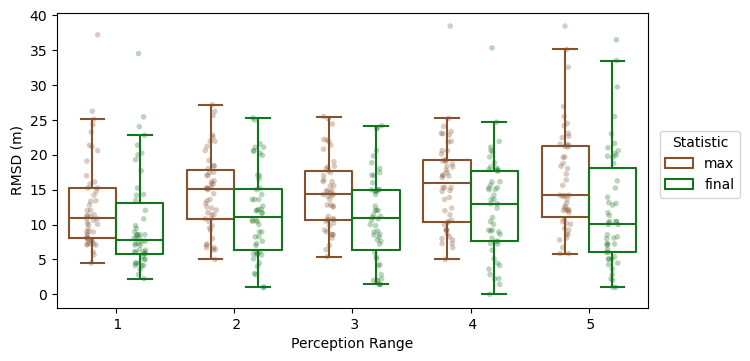

In [134]:
frog_loc_stats = pd.concat(
    [loc_data[key][1].groupby("frog", as_index=False).agg(
        max=("rmsd", "max"), final=("rmsd", "last"))
        .assign(scenario=key) for key in loc_data], ignore_index=True
).melt(
    id_vars=["frog", "scenario"],
    value_vars=["max", "final"],
    var_name="metric",
    value_name="value"
)

palette = [habitat_colours[i] for i in [0, 2]]

ax = sns.boxplot(
    data=frog_loc_stats,
    x="scenario",
    y="value",
    hue="metric",
    palette=[habitat_colours[i] for i in [0, 2]],
    fill = False,
    dodge=True,
    showfliers = False
)
sns.stripplot(
    data=frog_loc_stats,
    x="scenario",
    y="value",
    hue="metric",
    palette=[habitat_colours[i] for i in [0, 2]],
    dodge=True,
    jitter=0.1,
    alpha=0.3,
    size=4,
    linewidth=0,
    legend=False,
    ax=ax
)

# Formatting
plt.pyplot.legend(title="Statistic", bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.xlabel(x_label)
plt.pyplot.xticks(
    ticks=range(len(res_data)),
    labels=[scenario.replace("R_perc_", " ").replace("_"," ").title() for scenario in res_data.keys()]
)
plt.pyplot.ylabel("RMSD (m)")
plt.pyplot.tight_layout()

save_figure("distance_travelled")

## Frog trails

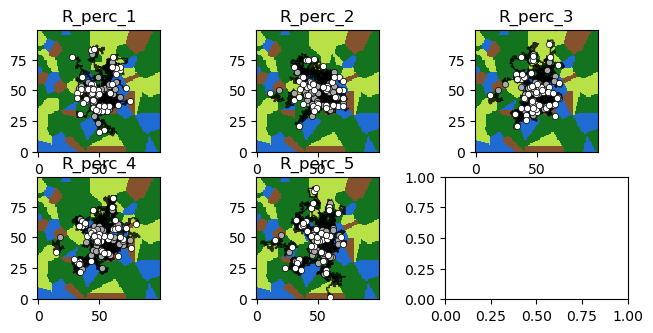

In [135]:
fig, axs = plt.pyplot.subplots(nrows=2, ncols=3, figsize=(8, 6))
axs_flat = axs.flatten()

for ax, key in zip(axs_flat[:-1], loc_data.keys()):
    mat_data = read_mat("output/" + key + ".mat")
    img = ax.imshow(
        mat_data["habitat"],
        cmap=cmap,
        vmin=0.5,
        vmax=4.5,
        interpolation="nearest",
        origin="lower"
    )
    ax.set_title(key)

    for frog_id, frog_track in loc_data[key][1].groupby("frog"):
        ax.plot(
            frog_track["x"],
            frog_track["y"],
            # color=frog_palette[int(frog_id)],
            color = "black",
            linewidth=1,
            alpha=0.8
        )
    for frog_id, frog_track in loc_data[key][1].groupby("frog"):
        ax.scatter(
            frog_track["x"].iloc[0],
            frog_track["y"].iloc[0],
            color="darkgrey",
            s=20,
            zorder=5,
            edgecolors="black",
            linewidths=0.5
        )
    for frog_id, frog_track in loc_data[key][1].groupby("frog"):
        ax.scatter(
            frog_track["x"].iloc[-1],
            frog_track["y"].iloc[-1],
            color="white",
            s=20,
            zorder=5,
            edgecolors="black",
            linewidths=0.5
        )

save_figure("frog_trails")

# plt.pyplot.gca().invert_yaxis()
# cbar = plt.pyplot.colorbar(img, ticks=[1,2,3,4])
# cbar.ax.set_yticklabels(mat_data["params"]["habitat_labels"])